# Rossmann Store Sales Forecasting
## Phase 5 - Machine Learning Pipeline

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("Install XGBoost with: !pip install xgboost")


## Load and Prepare Data

In [2]:
df = pd.read_csv(
    "/content/cleaned_sales.csv",
    low_memory=False,
    dtype={"StateHoliday": str}
)

df = df.drop(columns=["Date", "Customers"])

cat_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df = df.sort_values(["Year","Month","Day"])

split = int(len(df)*0.8)

train = df.iloc[:split]
test = df.iloc[split:]

X_train = train.drop("Sales", axis=1)
y_train = train["Sales"]

X_test = test.drop("Sales", axis=1)
y_test = test["Sales"]


## Model Training

In [3]:
def metrics(name, y_true, pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true,pred),
        "RMSE": np.sqrt(mean_squared_error(y_true,pred)),
        "R2": r2_score(y_true,pred)
    }

results=[]

lr=LinearRegression()
lr.fit(X_train,y_train)
pred_lr=lr.predict(X_test)
results.append(metrics("Linear Regression",y_test,pred_lr))

dt=DecisionTreeRegressor(max_depth=20,random_state=42)
dt.fit(X_train,y_train)
pred_dt=dt.predict(X_test)
results.append(metrics("Decision Tree",y_test,pred_dt))

rf=RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)
results.append(metrics("Random Forest",y_test,pred_rf))

best_model=rf
best_pred=pred_rf

if HAS_XGB:
    xgb=XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train,y_train)
    pred_xgb=xgb.predict(X_test)
    results.append(metrics("XGBoost",y_test,pred_xgb))
    best_model=xgb
    best_pred=pred_xgb

results_df=pd.DataFrame(results).sort_values("R2",ascending=False)
results_df


,Model,MAE,RMSE,R2
2,Random Forest,733.503702,1180.307634,0.906717
3,XGBoost,815.294312,1210.795348,0.901835
1,Decision Tree,819.835098,1328.509163,0.881820
0,Linear Regression,1702.645752,2455.390391,0.596304


## Feature Importance

,Feature,Importance
2,Open,0.294882
3,Promo,0.083615
20,StoreType_b,0.077517
19,StateHoliday_c,0.051905
17,StateHoliday_a,0.042585
1,DayOfWeek,0.040566
18,StateHoliday_b,0.034351
24,Assortment_c,0.030172
10,Promo2SinceYear,0.029120
5,CompetitionDistance,0.026609


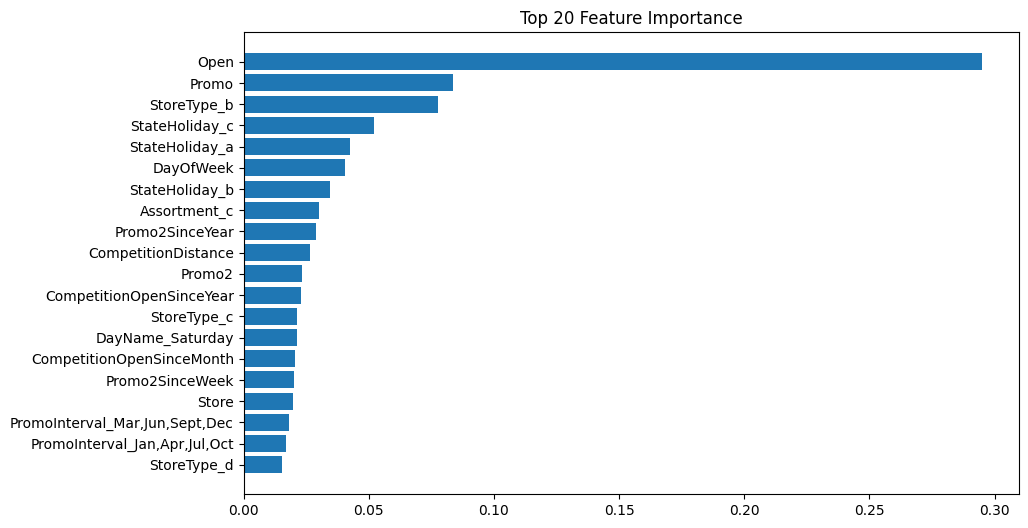

In [4]:
if hasattr(best_model,"feature_importances_"):
    importance=pd.DataFrame({
        "Feature":X_train.columns,
        "Importance":best_model.feature_importances_
    }).sort_values("Importance",ascending=False)

    display(importance.head(20))

    plt.figure(figsize=(10,6))
    plt.barh(
        importance.head(20)["Feature"][::-1],
        importance.head(20)["Importance"][::-1]
    )
    plt.title("Top 20 Feature Importance")
    plt.show()


## Predictions

,Actual,Predicted
0,9572,9243.781250
1,8170,8081.383789
2,6907,6613.555176
3,4478,5951.761230
4,11872,11666.472656
5,5556,6631.209473
6,4383,5910.930176
7,5335,6668.676270
8,9028,8650.962891
9,7877,8156.250488


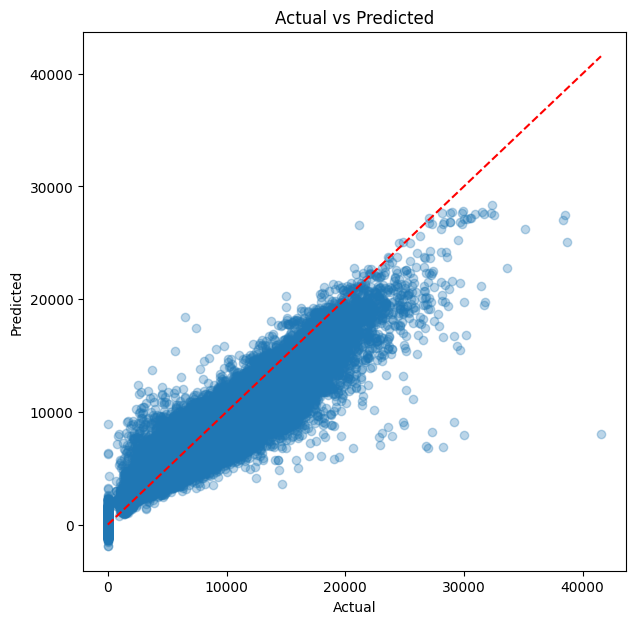

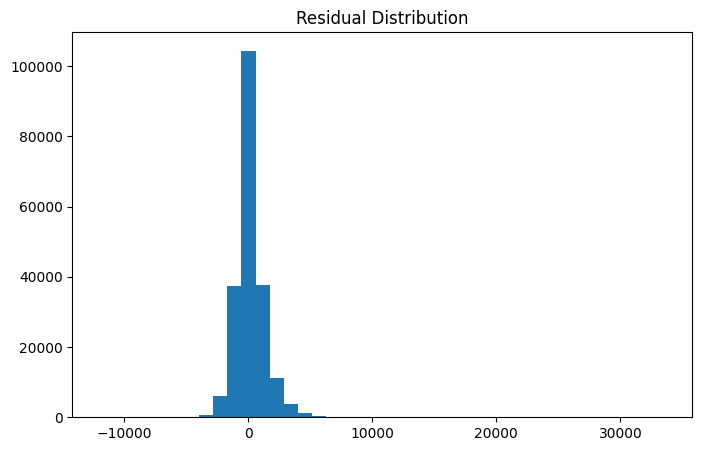

Model saved.


In [5]:
prediction_df=pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":best_pred
})

display(prediction_df.head(20))

plt.figure(figsize=(7,7))
plt.scatter(prediction_df["Actual"],prediction_df["Predicted"],alpha=0.3)
plt.plot(
    [prediction_df["Actual"].min(),prediction_df["Actual"].max()],
    [prediction_df["Actual"].min(),prediction_df["Actual"].max()],
    "r--"
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

errors=prediction_df["Actual"]-prediction_df["Predicted"]

plt.figure(figsize=(8,5))
plt.hist(errors,bins=40)
plt.title("Residual Distribution")
plt.show()

joblib.dump(best_model,"rossmann_sales_forecasting.pkl")
print("Model saved.")


**Business Conclusion**

The Random Forest model achieved the highest predictive performance with an R² score of approximately 0.91, outperforming Linear Regression, Decision Tree, and XGBoost. Feature importance analysis identified Store Open Status, Promotional Campaigns, and Store Type as the primary drivers of sales. The model demonstrates strong predictive capability and can support inventory planning, promotional strategy optimization, workforce scheduling, and revenue forecasting.

**Business Recommendations**

Continue investing in promotional campaigns because both SQL analysis and the ML model identified promotions as a major sales driver.
Use store-specific forecasts to improve inventory allocation and reduce stock-outs.
Increase staffing during periods where the model predicts high demand.
Monitor underperforming stores and benchmark practices from high-performing locations.

**Model Limitations**

The model is trained on historical data and may not capture unprecedented events.
Forecast accuracy decreases slightly for extremely high sales values.
External factors such as weather, economic conditions, and local events were not included.